# Fitness App Data Analysis

In this project, I will analyze a fitness dataset to understand user behavior, workout patterns, and what affects user drop-off.

The goal is to explore the data and find useful insights that can help improve user engagement.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

First, I load the dataset and take a quick look at it.

In [2]:
df = pd.read_csv("xclan_fitness_usage_dataset.csv")
df.head()

,user_id,session_date,session_duration_minutes,workout_module_used,calories_burned,completed_goal_checkin,signup_date,age,gender,goal,last_login_date,dropoff_flag
0,U0001,2025-05-13,30,Strength,153.41,No,2025-06-03,43,M,Build Muscle,2025-07-30,No
1,U0001,2025-05-15,66,Cardio,339.89,No,2025-06-03,43,M,Build Muscle,2025-07-30,No
2,U0001,2025-05-19,34,Cardio,214.16,Yes,2025-06-03,43,M,Build Muscle,2025-07-30,No
3,U0001,2025-05-22,88,Cardio,620.48,No,2025-06-03,43,M,Build Muscle,2025-07-30,No
4,U0001,2025-05-23,42,Cardio,322.88,Yes,2025-06-03,43,M,Build Muscle,2025-07-30,No


## Understanding the Data

I want to understand the structure of the dataset, including columns and data types.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 17425 entries, 0 to 17424
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   17425 non-null  str    
 1   session_date              17425 non-null  str    
 2   session_duration_minutes  17425 non-null  int64  
 3   workout_module_used       17425 non-null  str    
 4   calories_burned           17425 non-null  float64
 5   completed_goal_checkin    17425 non-null  str    
 6   signup_date               17425 non-null  str    
 7   age                       17425 non-null  int64  
 8   gender                    17425 non-null  str    
 9   goal                      17425 non-null  str    
 10  last_login_date           17425 non-null  str    
 11  dropoff_flag              17425 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 1.6 MB


,session_duration_minutes,calories_burned,age
count,17425.000000,17425.000000,17425.000000
mean,49.407518,370.534618,35.889928
std,23.021020,189.593632,10.507614
min,10.000000,50.210000,18.000000
25%,29.000000,214.120000,27.000000
50%,50.000000,355.550000,36.000000
75%,69.000000,507.200000,45.000000
max,89.000000,889.100000,54.000000


## Data Cleaning

In this step, I check for missing values and fix data types if needed.

In [4]:
df.isnull().sum()

user_id                     0
session_date                0
session_duration_minutes    0
workout_module_used         0
calories_burned             0
completed_goal_checkin      0
signup_date                 0
age                         0
gender                      0
goal                        0
last_login_date             0
dropoff_flag                0
dtype: int64

In [5]:
# Convert dates to datetime
df['session_date'] = pd.to_datetime(df['session_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_login_date'] = pd.to_datetime(df['last_login_date'])

## Feature Engineering

Here, I create new features that might help in analysis.

In [6]:
# مدة استخدام التطبيق (بالأيام)
df['days_active'] = (df['last_login_date'] - df['signup_date']).dt.days

# الشهر
df['month'] = df['session_date'].dt.month

## Session Duration Analysis

I want to see how long users spend per session.

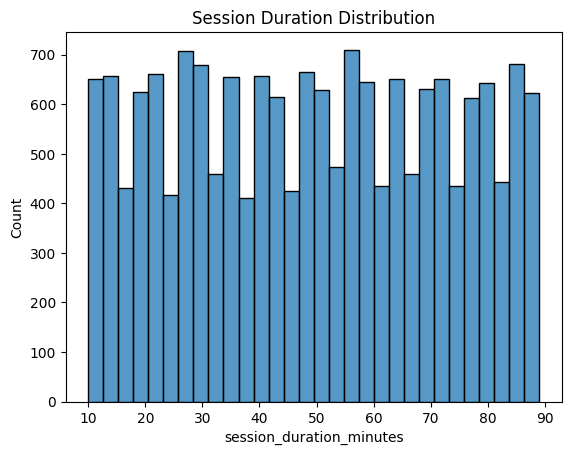

In [7]:
plt.figure()
sns.histplot(df['session_duration_minutes'], bins=30)
plt.title("Session Duration Distribution")
plt.show()

- Most users spend a moderate amount of time per session, with fewer users having very long sessions.

---

## Calories Burned

Now I explore how many calories users burn.

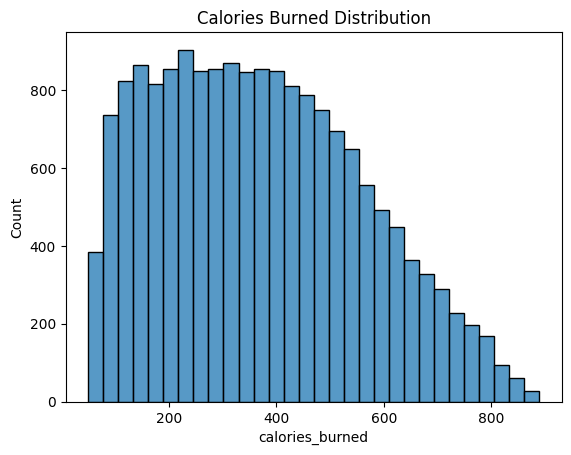

In [8]:
plt.figure()
sns.histplot(df['calories_burned'], bins=30)
plt.title("Calories Burned Distribution")
plt.show()

- Calories burned varies between users, but most sessions fall within a common range.

---

## Goal vs Drop-off

I want to see if user goals affect whether they stop using the app.

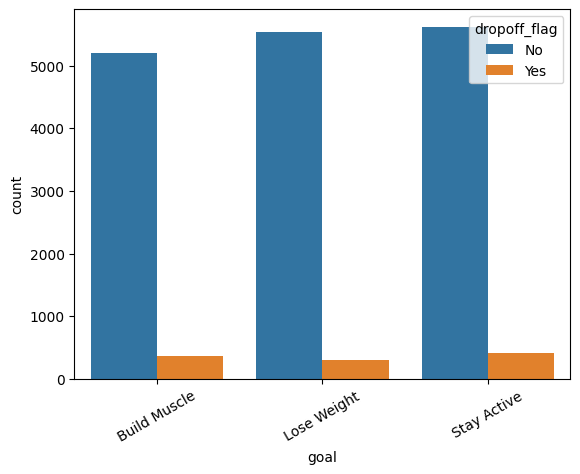

In [9]:
plt.figure()
sns.countplot(data=df, x='goal', hue='dropoff_flag')
plt.xticks(rotation=30)
plt.show()

- Some goals seem to have higher drop-off rates, which might indicate lower engagement.

---

## Gender Distribution

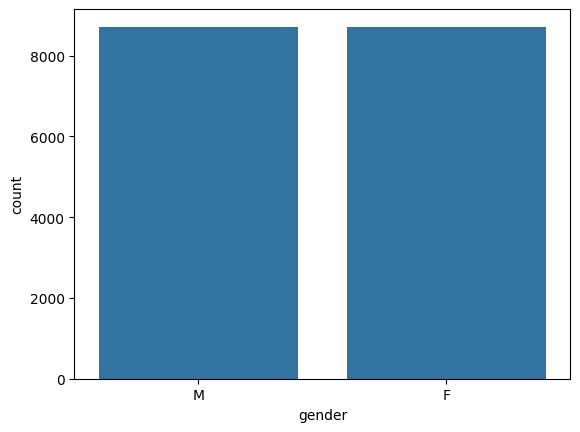

In [10]:
sns.countplot(data=df, x='gender')
plt.show()

- The dataset shows how users are distributed across genders.
---

## Age Distribution

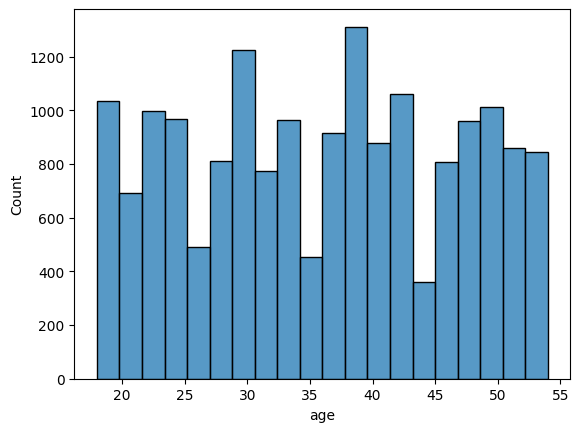

In [11]:
sns.histplot(df['age'], bins=20)
plt.show()

- Most users fall within a specific age range, indicating the target audience of the app.
---

## Final Insights

- Users with longer activity duration tend to stay more engaged.
- Some workout goals may lead to higher drop-off.
- Session duration and calories burned are consistent for most users.
- The app seems to target a specific age group.

## Conclusion

This analysis helps understand user behavior and can be useful for improving user retention and experience.